In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tensorflow.random import set_seed
import random

In [232]:
seed = 42
np.random.seed(seed)
random.seed(seed)
set_seed(seed)

In [233]:
def dcr(func):
    def wrapper(*args):
        print("=" * 150)
        func(*args)
        print("=" * 150)
    return wrapper

@dcr
def pretty_print(*args):
    print(*args)

In [234]:
data = np.array(pd.read_csv('mnist_train.csv'))

In [235]:
X = data[:, 1:]
y = data[:, 0]



X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_scaled = X_train / 255
X_valid_scaled = X_valid / 255

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_valid = to_categorical(y_valid, 10)

pretty_print("Number of unlabeled data :", pd.isna(y).sum(), ", Training samples:", X_train.shape, ",Test samples:", X_valid.shape)


Number of unlabeled data : 0 , Training samples: (47999, 784) ,Test samples: (12000, 784)


In [236]:
# Randomly choose 5% of the data to reduce resource consumption for different regularizers

tiny_size = int(len(X_train) * 0.05)

indices = np.random.choice(
    len(X_train),
    tiny_size,
    replace=False
)

x_tiny = X_train_scaled[indices]
y_tiny = y_train[indices]

pretty_print("X tiny Shape: ", x_tiny.shape,", y tiny Shape: ", y_tiny.shape)

X tiny Shape:  (2399, 784) , y tiny Shape:  (2399, 10)


In [237]:
x_train_tiny, x_val, y_train_tiny, y_val = train_test_split(
    x_tiny,
    y_tiny,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_tiny, axis=1)
)

## Building the Base Model

In [238]:
def build_M1():

    model = Sequential()

    model.add(Dense(
        20,
        activation='relu',
        input_shape=(784,)
    ))

    model.add(Dense(
        20,
        activation='relu'
    ))

    model.add(Dense(
        10,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [239]:
M1 = build_M1()

history_M1 = M1.fit(
    x_train_tiny,
    y_train_tiny,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1,
    callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
)

Epoch 1/30


C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1724 - loss: 2.2759 - val_accuracy: 0.3146 - val_loss: 2.0052
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3952 - loss: 1.8438 - val_accuracy: 0.4667 - val_loss: 1.4923
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5780 - loss: 1.3118 - val_accuracy: 0.7167 - val_loss: 1.0723
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7893 - loss: 0.9190 - val_accuracy: 0.7875 - val_loss: 0.8175
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8409 - loss: 0.6978 - val_accuracy: 0.8271 - val_loss: 0.6778
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8621 - loss: 0.5709 - val_accuracy: 0.8396 - val_loss: 0.5976
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8783 - loss: 0.4914 - val_accuracy: 0.8417 - val_loss: 0.5441
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8886 - loss: 0.4346 - val_accuracy: 0.8542 - val_loss: 0.5043
Epo

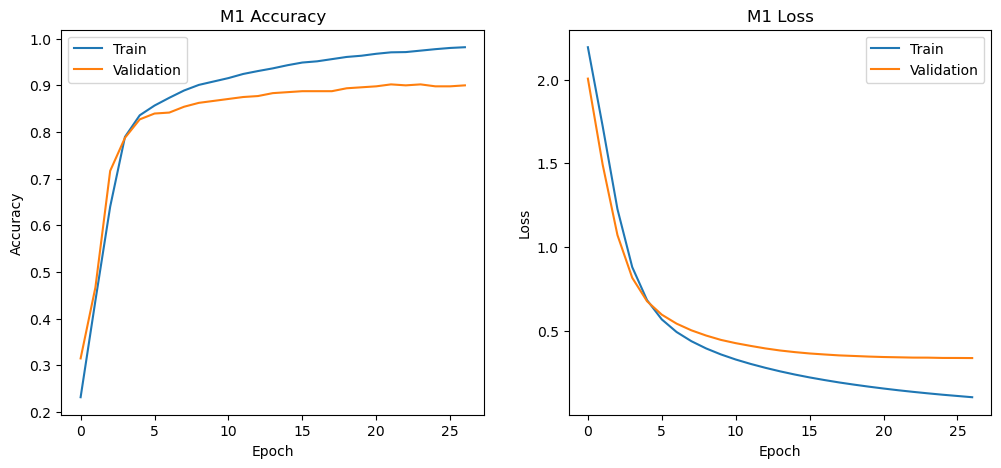

In [240]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train","Validation"])

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train","Validation"])

    plt.show()
    
plot_history(history_M1, "M1")

In [241]:
best_epoch_M1 = np.argmax(history_M1.history['val_accuracy'])
train_acc_M1 = history_M1.history['accuracy'][best_epoch_M1]
val_acc_M1 = history_M1.history['val_accuracy'][best_epoch_M1]

gap_M1 = train_acc_M1 - val_acc_M1

pretty_print(
            "[M1 Results]: The best epoch is calculated based on the validation accuracy.\n", "\nGeneralization Gap =", gap_M1,
    "\nBest epoch val accuracy =", val_acc_M1,
    "\nBest epoch training accuracy =", train_acc_M1,
            """
            
| Gap  | Conclusion         |
|------|--------------------|
| < 2% | Good               |
| 2-5% | Mild overfitting   |
| > 5% | Strong overfitting |
            """)

[M1 Results]: The best epoch is calculated based on the validation accuracy.
 
Generalization Gap = 0.06873482465744019 
Best epoch val accuracy = 0.9020833373069763 
Best epoch training accuracy = 0.9708181619644165 
            
| Gap  | Conclusion         |
|------|--------------------|
| < 2% | Good               |
| 2-5% | Mild overfitting   |
| > 5% | Strong overfitting |
            


In [242]:
lambda_l1 = 1e-7

def build_L1_M1(lambda_l1):

    model = Sequential()

    model.add(Dense(
        20,
        activation='relu',
        kernel_regularizer=l1(lambda_l1),
        input_shape=(784,)
    ))

    model.add(Dense(
        20,
        activation='relu',
        kernel_regularizer=l1(lambda_l1)
    ))

    model.add(Dense(
        10,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [243]:
L1_M1 = build_L1_M1(1e-7)

history_L1 = L1_M1.fit(
    x_train_tiny,
    y_train_tiny,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1469 - loss: 2.2787 - val_accuracy: 0.3292 - val_loss: 2.0376
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4153 - loss: 1.9188 - val_accuracy: 0.5646 - val_loss: 1.5479
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6640 - loss: 1.3824 - val_accuracy: 0.7521 - val_loss: 1.0238
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7938 - loss: 0.8961 - val_accuracy: 0.8146 - val_loss: 0.7263
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8468 - loss: 0.6384 - val_accuracy: 0.8458 - val_loss: 0.5952
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8771 - loss: 0.5106 - val_accuracy: 0.8646 - val_loss: 0.5253
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8986 - loss: 0.4369 - val_accuracy: 0.8729 - val_loss: 0.4789
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9102 - loss: 0.3865 - val_accuracy: 0.8792 - val_loss:

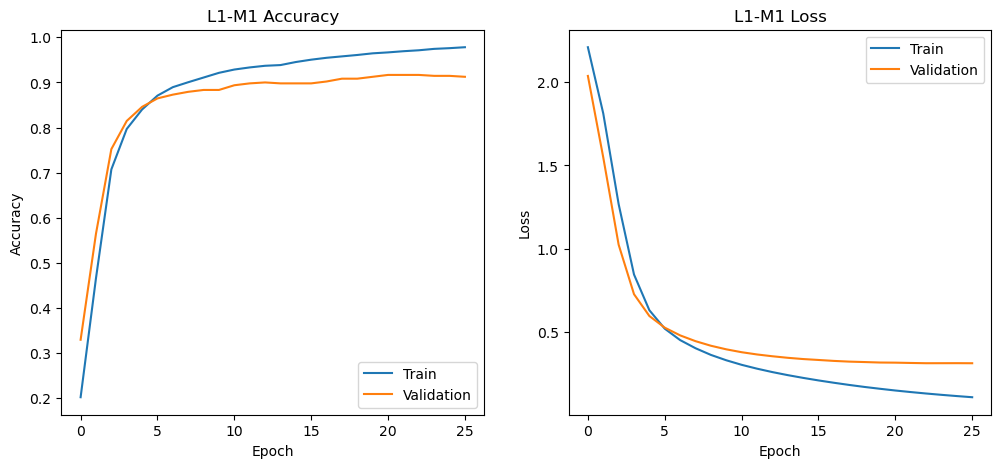

In [244]:
plot_history(history_L1, "L1-M1")

In [245]:
lambdas = [
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2
]

In [246]:
results_l1 = []

for lam in lambdas:

    model = build_L1_M1(lam)

    history = model.fit(
        x_train_tiny,
        y_train_tiny,
        validation_data=(x_val,y_val),
        epochs=30,
        verbose=0,
        callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
    )

    val_acc = max(history.history['val_accuracy'])

    results_l1.append(
        [lam, val_acc]
    )

results_l1 = pd.DataFrame(
    results_l1,
    columns=['Lambda','Val Accuracy']
)

pretty_print(results_l1)

         Lambda  Val Accuracy
0  1.000000e-08      0.916667
1  1.000000e-07      0.916667
2  1.000000e-06      0.900000
3  1.000000e-05      0.906250
4  1.000000e-04      0.889583
5  1.000000e-03      0.912500
6  1.000000e-02      0.868750


In [247]:
results_l1.sort_values(by="Val Accuracy", inplace=True, ascending=False)
max_result_l1_lam = results_l1.iloc[0]["Lambda"]
pretty_print("Lambda with the highest validation accuracy: ", max_result_l1_lam)

Lambda with the highest validation accuracy:  1e-08


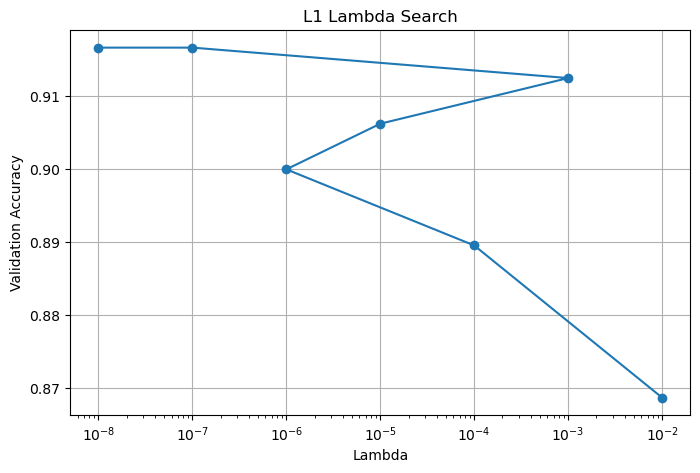

In [248]:
plt.figure(figsize=(8,5))

plt.semilogx(
    results_l1['Lambda'],
    results_l1['Val Accuracy'],
    marker='o'
)

plt.xlabel("Lambda")
plt.ylabel("Validation Accuracy")
plt.title("L1 Lambda Search")
plt.grid(True)

plt.show()

In [249]:
def create_refine_space(best_lambda):
    best_lambda = float(best_lambda)
    space =[
        best_lambda * 0.1,
        best_lambda * 0.3,
        best_lambda * 0.5,
        best_lambda * 0.7,
        best_lambda * 0.9,
        best_lambda * 1.0,
        best_lambda * 1.1,
        best_lambda * 1.3,
        best_lambda * 1.5,
        best_lambda * 1.7,
        best_lambda * 2.0,
    ]
    
    return space

In [250]:
refined_lambdas = create_refine_space(max_result_l1_lam)

refined_results_l1 = []

for lam in refined_lambdas:

    model = build_L1_M1(lam)

    history = model.fit(
        x_train_tiny,
        y_train_tiny,
        validation_data=(x_val,y_val),
        epochs=30,
        verbose=0,
        callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
    )

    val_acc = max(history.history['val_accuracy'])

    refined_results_l1.append(
        [lam, val_acc]
    )

refined_results_l1 = pd.DataFrame(
    refined_results_l1,
    columns=['Refined Lambda','Val Accuracy']
)

pretty_print(refined_results_l1)

C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Refined Lambda  Val Accuracy
0     1.000000e-09      0.906250
1     3.000000e-09      0.893750
2     5.000000e-09      0.906250
3     7.000000e-09      0.912500
4     9.000000e-09      0.912500
5     1.000000e-08      0.914583
6     1.100000e-08      0.906250
7     1.300000e-08      0.904167
8     1.500000e-08      0.910417
9     1.700000e-08      0.925000
10    2.000000e-08      0.908333


In [251]:
refined_results_l1.sort_values(by="Val Accuracy", inplace=True, ascending=False)
lambda_opt_L1 = refined_results_l1.iloc[0]["Refined Lambda"]
pretty_print("Refined Lambda with the highest validation accuracy : ", lambda_opt_L1)

Refined Lambda with the highest validation accuracy :  1.7e-08


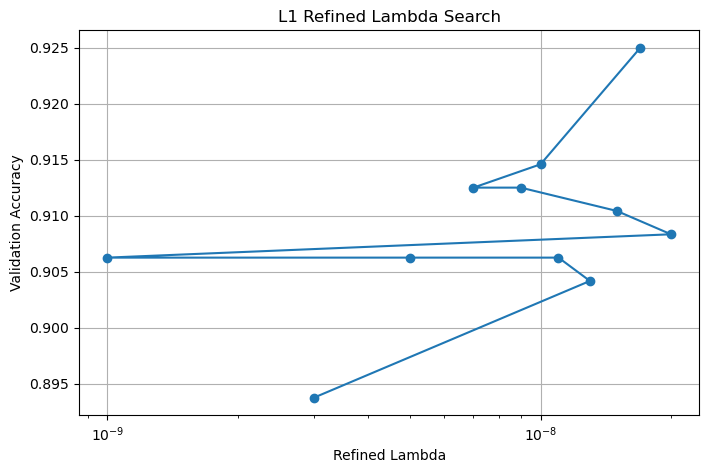

In [252]:
plt.figure(figsize=(8,5))

plt.semilogx(
    refined_results_l1['Refined Lambda'],
    refined_results_l1['Val Accuracy'],
    marker='o'
)

plt.xlabel("Refined Lambda")
plt.ylabel("Validation Accuracy")
plt.title("L1 Refined Lambda Search")
plt.grid(True)

plt.show()

In [253]:
l1_opt_model = build_L1_M1(float(lambda_opt_L1))


l1_opt_history = l1_opt_model.fit(
        x_train_tiny,
        y_train_tiny,
        validation_data=(x_val,y_val),
        epochs=30,
        verbose=0,
        callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
    )

C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [254]:
best_epoch_l1 = np.argmax(l1_opt_history.history['val_accuracy'])
train_acc_l1 = l1_opt_history.history['accuracy'][best_epoch_l1]
val_acc_l1 = l1_opt_history.history['val_accuracy'][best_epoch_l1]

gap_l1 = train_acc_l1 - val_acc_l1

pretty_print(
            "[L1 Results]: The best epoch is calculated based on the validation accuracy.\n", "\nGeneralization Gap =", gap_l1,
    "\nBest epoch val accuracy =", val_acc_l1,
    "\nBest epoch training accuracy =", train_acc_l1,
            """
            
| Gap  | Conclusion         |
|------|--------------------|
| < 2% | Good               |
| 2-5% | Mild overfitting   |
| > 5% | Strong overfitting |
            """)

[L1 Results]: The best epoch is calculated based on the validation accuracy.
 
Generalization Gap = 0.061450183391571045 
Best epoch val accuracy = 0.9229166507720947 
Best epoch training accuracy = 0.9843668341636658 
            
| Gap  | Conclusion         |
|------|--------------------|
| < 2% | Good               |
| 2-5% | Mild overfitting   |
| > 5% | Strong overfitting |
            


In [255]:
def build_L2_M1(lambda_l2):

    model = Sequential()

    model.add(Dense(
        20,
        activation='relu',
        kernel_regularizer=l2(lambda_l2),
        input_shape=(784,)
    ))

    model.add(Dense(
        20,
        activation='relu',
        kernel_regularizer=l2(lambda_l2)
    ))

    model.add(Dense(
        10,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [256]:
L2_M1 = build_L2_M1(1e-7)

history_L2 = L2_M1.fit(
    x_train_tiny,
    y_train_tiny,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2773 - loss: 2.1429 - val_accuracy: 0.4896 - val_loss: 1.6653
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5581 - loss: 1.5212 - val_accuracy: 0.7167 - val_loss: 1.1210
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7634 - loss: 1.0156 - val_accuracy: 0.8104 - val_loss: 0.7896
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8418 - loss: 0.7193 - val_accuracy: 0.8396 - val_loss: 0.6308
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8669 - loss: 0.5677 - val_accuracy: 0.8604 - val_loss: 0.5439
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8819 - loss: 0.4805 - val_accuracy: 0.8646 - val_loss: 0.4889
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8949 - loss: 0.4201 - val_accuracy: 0.8771 - val_loss: 0.4505
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9089 - loss: 0.3760 - val_accuracy: 0.8792 - val_loss:

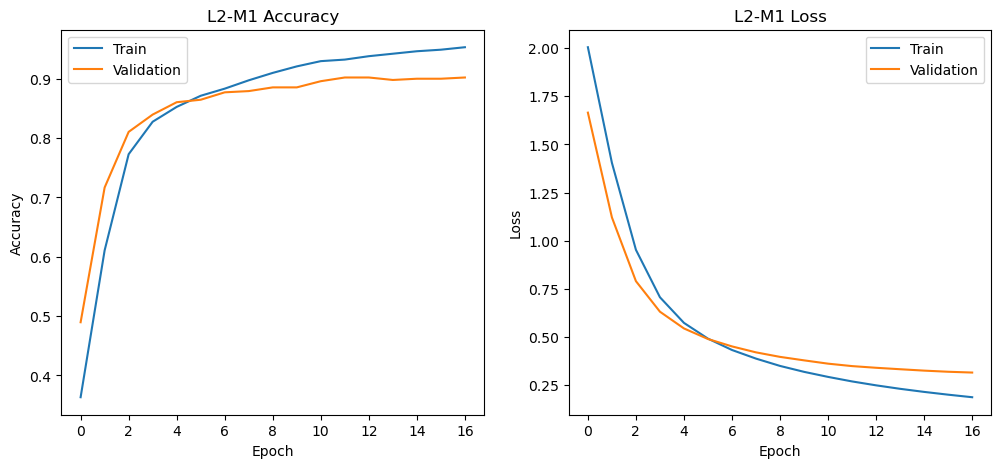

In [257]:
plot_history(history_L2, "L2-M1")

In [258]:
results_l2 = []

for lam in lambdas:

    model = build_L2_M1(lam)

    history = model.fit(
        x_train_tiny,
        y_train_tiny,
        validation_data=(x_val,y_val),
        epochs=30,
        verbose=0,
        callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
    )

    val_acc = max(history.history['val_accuracy'])

    results_l2.append(
        [lam, val_acc]
    )

results_l2 = pd.DataFrame(
    results_l2,
    columns=['Lambda','Val Accuracy']
)

pretty_print(results_l2)

         Lambda  Val Accuracy
0  1.000000e-08      0.916667
1  1.000000e-07      0.912500
2  1.000000e-06      0.895833
3  1.000000e-05      0.902083
4  1.000000e-04      0.908333
5  1.000000e-03      0.900000
6  1.000000e-02      0.893750


In [259]:
results_l2.sort_values(by="Val Accuracy", inplace=True, ascending=False)
max_result_l2_lam = results_l2.iloc[0]["Lambda"]
pretty_print("Lambda with the highest validation accuracy: ", max_result_l2_lam)

Lambda with the highest validation accuracy:  1e-08


In [260]:
refined_lambdas = create_refine_space(max_result_l2_lam)

refined_results_l2 = []

for lam in refined_lambdas:

    model = build_L2_M1(lam)

    history = model.fit(
        x_train_tiny,
        y_train_tiny,
        validation_data=(x_val,y_val),
        epochs=30,
        verbose=0,
        callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
    )

    val_acc = max(history.history['val_accuracy'])

    refined_results_l2.append(
        [lam, val_acc]
    )

refined_results_l2 = pd.DataFrame(
    refined_results_l2,
    columns=['Refined Lambda','Val Accuracy']
)

pretty_print(refined_results_l2)

C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Refined Lambda  Val Accuracy
0     1.000000e-09      0.902083
1     3.000000e-09      0.908333
2     5.000000e-09      0.908333
3     7.000000e-09      0.916667
4     9.000000e-09      0.912500
5     1.000000e-08      0.904167
6     1.100000e-08      0.927083
7     1.300000e-08      0.922917
8     1.500000e-08      0.922917
9     1.700000e-08      0.902083
10    2.000000e-08      0.900000


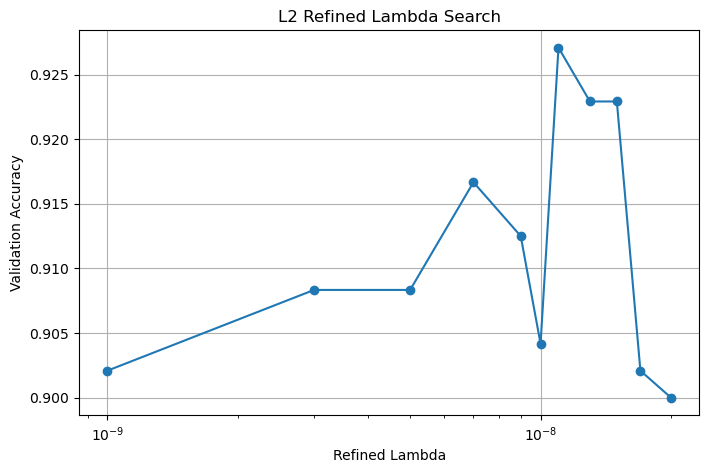

In [261]:
plt.figure(figsize=(8,5))

plt.semilogx(
    refined_results_l2['Refined Lambda'],
    refined_results_l2['Val Accuracy'],
    marker='o'
)

plt.xlabel("Refined Lambda")
plt.ylabel("Validation Accuracy")
plt.title("L2 Refined Lambda Search")
plt.grid(True)

plt.show()

In [262]:
refined_results_l2.sort_values(by="Val Accuracy", inplace=True, ascending=False)
lambda_opt_L2 = refined_results_l2.iloc[0]["Refined Lambda"]
pretty_print("Refined Lambda with the highest validation accuracy : ", lambda_opt_L2)

Refined Lambda with the highest validation accuracy :  1.1000000000000001e-08


In [263]:
l2_opt_model = build_L2_M1(float(lambda_opt_L2))


l2_opt_history = l2_opt_model.fit(
        x_train_tiny,
        y_train_tiny,
        validation_data=(x_val,y_val),
        epochs=30,
        verbose=0,
        callbacks=[
        callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
    )

C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [264]:
best_epoch_l2 = np.argmax(l2_opt_history.history['val_accuracy'])
train_acc_l2 = l2_opt_history.history['accuracy'][best_epoch_l2]
val_acc_l2 = l2_opt_history.history['val_accuracy'][best_epoch_l2]

gap_l2 = train_acc_l2 - val_acc_l2

pretty_print(
            "[L2 Results]: The best epoch is calculated based on the validation accuracy.\n", "\nGeneralization Gap =", gap_l2,
    "\nBest epoch val accuracy =", val_acc_l2,
    "\nBest epoch training accuracy =", train_acc_l2,
            """
            
| Gap  | Conclusion         |
|------|--------------------|
| < 2% | Good               |
| 2-5% | Mild overfitting   |
| > 5% | Strong overfitting |
            """)

[L2 Results]: The best epoch is calculated based on the validation accuracy.
 
Generalization Gap = 0.06352812051773071 
Best epoch val accuracy = 0.9104166626930237 
Best epoch training accuracy = 0.9739447832107544 
            
| Gap  | Conclusion         |
|------|--------------------|
| < 2% | Good               |
| 2-5% | Mild overfitting   |
| > 5% | Strong overfitting |
            


In [265]:
# We have already calculated the gap , val acc and acc for base model, with l1 and l2 regularization (train_acc, val_acc, gap), now we'll only compare the results 
pd.DataFrame ({
    'Model': [
        'M1',
        'L1-M1',
        'L2-M1'
    ],

    'Train Acc': [
        train_acc_M1,
        train_acc_l1,
        train_acc_l2
    ],

    'Validation Acc': [
        val_acc_M1,
        val_acc_l1,
        val_acc_l2
    ],

    'Gap': [
        gap_M1,
        gap_l1,
        gap_l2
    ]
})

,Model,Train Acc,Validation Acc,Gap
0,M1,0.970818,0.902083,0.068735
1,L1-M1,0.984367,0.922917,0.061450
2,L2-M1,0.973945,0.910417,0.063528


Based on the above results, we can assume that L1 regularizer performed better in reducing the gap between training accuracy and validation accuracy but L2  achieved a better validation accuracy.

In [266]:
def build_M2(lambda_opt, best_reg, dropout_rate):

    model = Sequential()

    model.add(Dense(
        20,
        activation='relu',
        kernel_regularizer=best_reg(lambda_opt),
        input_shape=(784,)
    ))

    model.add(Dropout(dropout_rate))

    model.add(Dense(
        20,
        activation='relu',
        kernel_regularizer=best_reg(lambda_opt)
    ))

    model.add(Dropout(dropout_rate))

    model.add(Dense(
        10,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [267]:
dropout_rates = np.linspace(0.01,0.99,22)

M2_dropout_result = []

for dropout_rate in dropout_rates:
    M2 = build_M2(float(lambda_opt_L1), l1, dropout_rate)
    
    history_M2 = M2.fit(
        x_train_tiny,
        y_train_tiny,
        validation_data=(x_val,y_val),
        epochs=30,
        batch_size=64,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ]
    )
    
    train_loss, train_acc = M2.evaluate(
        x_train_tiny,
        y_train_tiny,
        verbose=0
    )
    
    val_loss, val_acc = M2.evaluate(
        x_val,
        y_val,
        verbose=0
    )
    
    gap = train_acc - val_acc

    M2_dropout_result.append(
        [dropout_rate, train_acc, val_acc, gap]
    )

results_M2 = pd.DataFrame(
    M2_dropout_result,
    columns=['Dropout', 'Training Accuracy','Val Accuracy', "Gap"]
)

pretty_print(results_M2)

Epoch 1/30


C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2051 - loss: 2.2314 - val_accuracy: 0.3958 - val_loss: 1.9293
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4550 - loss: 1.8056 - val_accuracy: 0.5771 - val_loss: 1.4523
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6204 - loss: 1.3298 - val_accuracy: 0.7646 - val_loss: 1.0289
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7797 - loss: 0.9371 - val_accuracy: 0.8188 - val_loss: 0.7541
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8409 - loss: 0.6951 - val_accuracy: 0.8542 - val_loss: 0.6070
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8739 - loss: 0.5580 - val_accuracy: 0.8667 - val_loss: 0.5290
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8897 - loss: 0.4641 - val_accuracy: 0.8750 - val_loss: 0.4725
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8890 - loss: 0.4378 - val_accuracy: 0.8875 - val_loss: 0.4425
Ep

In [268]:
results_M2.sort_values(by="Val Accuracy", inplace=True, ascending=False)
pretty_print(results_M2)

     Dropout  Training Accuracy  Val Accuracy       Gap
3   0.150000           0.955185      0.918750  0.036435
1   0.056667           0.971339      0.908333  0.063006
5   0.243333           0.945284      0.908333  0.036951
0   0.010000           0.941636      0.906250  0.035386
2   0.103333           0.935383      0.904167  0.031216
4   0.196667           0.934862      0.897917  0.036945
6   0.290000           0.922876      0.897917  0.024960
9   0.430000           0.916102      0.889583  0.026519
7   0.336667           0.936425      0.885417  0.051009
12  0.570000           0.896300      0.883333  0.012967
8   0.383333           0.890568      0.879167  0.011401
11  0.523333           0.911412      0.875000  0.036412
10  0.476667           0.899948      0.870833  0.029115
13  0.616667           0.865034      0.850000  0.015034
14  0.663333           0.859302      0.835417  0.023885
15  0.710000           0.653986      0.654167 -0.000180
16  0.756667           0.590933      0.591667 -0

According to the table, model with the dropout rate of 0.150000 clearly has much better generalization, since it has the highest validation accuracy and meanwhile having a near-zero gap, indicating less overfitting. Therefore the optimal value for dropout rate is 0.150000 in this case.

In [304]:
best_reg = l1 # These values are based of the previous steps of this notebook
best_lambda = lambda_opt_L1
opt_dropout_rate = 0.150000

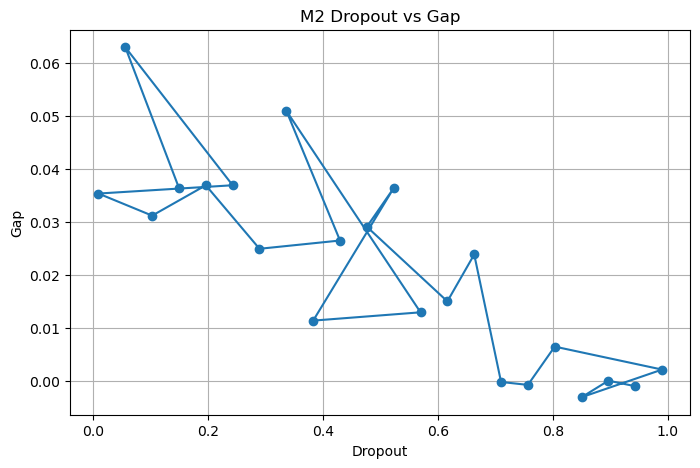

In [315]:
plt.figure(figsize=(8,5))

plt.plot(
    results_M2['Dropout'],
    results_M2['Gap'],
    marker='o'
)

plt.xlabel("Dropout")
plt.ylabel("Gap")
plt.title("M2 Dropout vs Gap")
plt.grid(True)

plt.show()

In [371]:
candidate_model_L1 = build_L1_M1(float(lambda_opt_L1)) 

opt_l1_model_history = candidate_model_L1.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=128,
        batch_size=256,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_accuracy", patience=32, restore_best_weights=True),
        ]
    )

Epoch 1/128


C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5637 - loss: 1.4489 - val_accuracy: 0.8882 - val_loss: 0.4057
Epoch 2/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8973 - loss: 0.3651 - val_accuracy: 0.9110 - val_loss: 0.3111
Epoch 3/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9170 - loss: 0.2874 - val_accuracy: 0.9230 - val_loss: 0.2634
Epoch 4/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9282 - loss: 0.2427 - val_accuracy: 0.9297 - val_loss: 0.2378
Epoch 5/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9363 - loss: 0.2170 - val_accuracy: 0.9344 - val_loss: 0.2215
Epoch 6/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9427 - loss: 0.1989 - val_accuracy: 0.9390 - val_loss: 0.2097
Epoch 7/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9473 - loss: 0.1851 - val_accuracy: 0.9416 - val_loss: 0.2012
Epoch 8/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9501 - loss: 0.1744 - val_accuracy: 0.9445

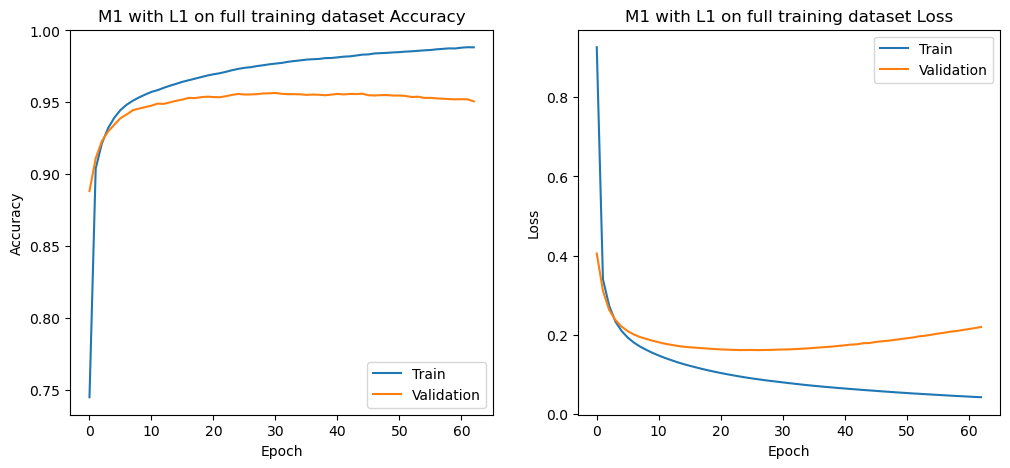

In [391]:
plot_history(opt_l1_model_history, "M1 with L1 on full training dataset")

In [373]:
candidate_model_L2 = build_L2_M1(float(lambda_opt_L2)) 

opt_l2_model_history = candidate_model_L2.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=128,
        batch_size=256,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_accuracy", patience=32, restore_best_weights=True),
        ]
    )

Epoch 1/128


C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5514 - loss: 1.4480 - val_accuracy: 0.8894 - val_loss: 0.3989
Epoch 2/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9004 - loss: 0.3576 - val_accuracy: 0.9139 - val_loss: 0.2995
Epoch 3/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9204 - loss: 0.2799 - val_accuracy: 0.9244 - val_loss: 0.2637
Epoch 4/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9293 - loss: 0.2469 - val_accuracy: 0.9300 - val_loss: 0.2427
Epoch 5/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9355 - loss: 0.2256 - val_accuracy: 0.9351 - val_loss: 0.2277
Epoch 6/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9399 - loss: 0.2095 - val_accuracy: 0.9388 - val_loss: 0.2171
Epoch 7/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9434 - loss: 0.1967 - val_accuracy: 0.9417 - val_loss: 0.2084
Epoch 8/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9464 - loss: 0.1858 - val_accuracy: 0.9429

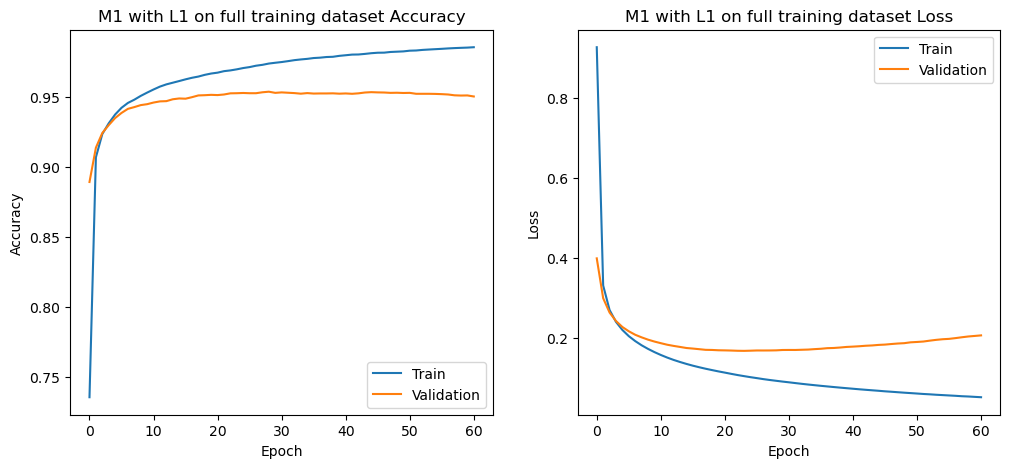

In [392]:
plot_history(opt_l2_model_history, "M1 with L1 on full training dataset")

In [375]:
candidate_model_M1 = build_M1() 

opt_model_history_M1 = candidate_model_M1.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=128,
        batch_size=256,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_accuracy", patience=32, restore_best_weights=True),
        ]
    )

Epoch 1/128


C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5181 - loss: 1.5154 - val_accuracy: 0.8929 - val_loss: 0.3909
Epoch 2/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8990 - loss: 0.3567 - val_accuracy: 0.9184 - val_loss: 0.2934
Epoch 3/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9222 - loss: 0.2744 - val_accuracy: 0.9287 - val_loss: 0.2522
Epoch 4/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9334 - loss: 0.2343 - val_accuracy: 0.9373 - val_loss: 0.2276
Epoch 5/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9405 - loss: 0.2089 - val_accuracy: 0.9413 - val_loss: 0.2119
Epoch 6/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9460 - loss: 0.1905 - val_accuracy: 0.9442 - val_loss: 0.2000
Epoch 7/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9506 - loss: 0.1763 - val_accuracy: 0.9465 - val_loss: 0.1908
Epoch 8/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9538 - loss: 0.1647 - val_accuracy: 0.9483

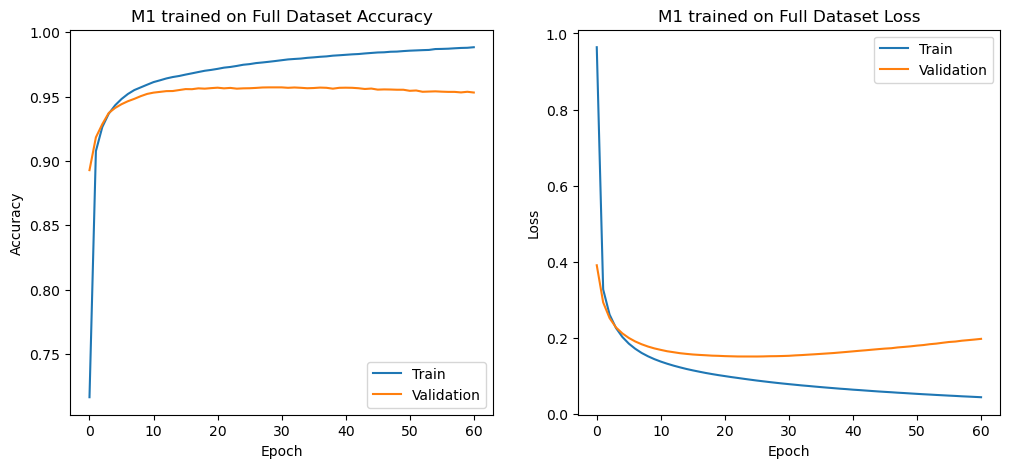

In [393]:
plot_history(opt_model_history_M1, "M1 trained on Full Dataset")

In [387]:
candidate_model_M2 = build_M2(float(best_lambda), best_reg, opt_dropout_rate) 

opt_model_history_M2 = candidate_model_M2.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_valid_scaled, y_valid),
        epochs=128,
        batch_size=256,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_accuracy", patience=32, restore_best_weights=True),
        ]
    )

Epoch 1/128


C:\Users\Pouyan\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4262 - loss: 1.6575 - val_accuracy: 0.8808 - val_loss: 0.4720
Epoch 2/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8039 - loss: 0.6412 - val_accuracy: 0.9010 - val_loss: 0.3478
Epoch 3/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8439 - loss: 0.5194 - val_accuracy: 0.9115 - val_loss: 0.3053
Epoch 4/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8592 - loss: 0.4570 - val_accuracy: 0.9178 - val_loss: 0.2785
Epoch 5/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8709 - loss: 0.4224 - val_accuracy: 0.9231 - val_loss: 0.2631
Epoch 6/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8804 - loss: 0.3967 - val_accuracy: 0.9278 - val_loss: 0.2494
Epoch 7/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8851 - loss: 0.3744 - val_accuracy: 0.9312 - val_loss: 0.2406
Epoch 8/128
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8907 - loss: 0.3602 - val_accuracy: 0.9332

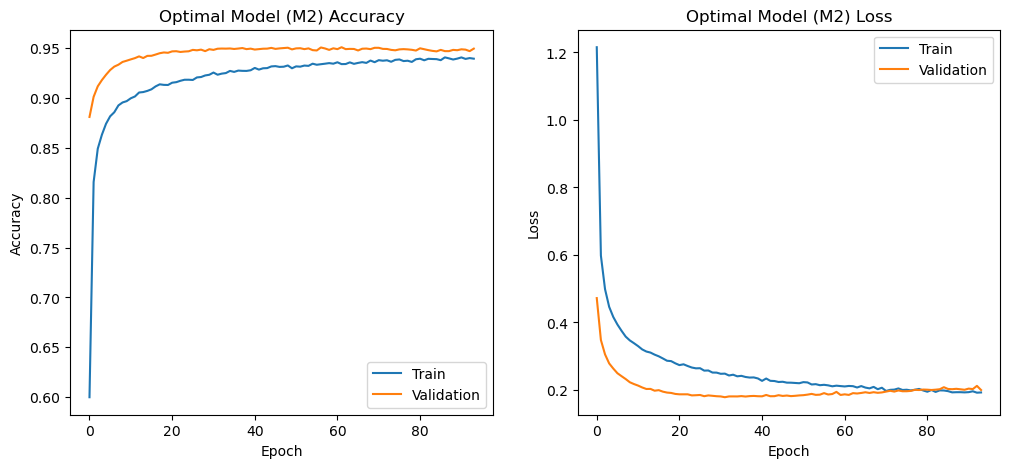

In [394]:
plot_history(opt_model_history_M2, "Optimal Model (M2)")

In [395]:
test_data = np.array(pd.read_csv("mnist_test.csv"))

X_test = test_data[:, 1:]
y_test = test_data[:, 0]


X_test_scaled = X_test / 255

# One-hot encoding
y_test = to_categorical(y_test, 10)

In [400]:
M2_loss, M2_acc = candidate_model_M2.evaluate(X_test_scaled, y_test, verbose=0)
M1_loss, M1_acc = candidate_model_M1.evaluate(X_test_scaled, y_test, verbose=0)
L1_loss, L1_acc = candidate_model_L1.evaluate(X_test_scaled, y_test, verbose=0)
L2_loss, L2_acc = candidate_model_L2.evaluate(X_test_scaled, y_test, verbose=0)

print("[M2    ] Loss on test dataset: ", M2_loss," "*3, ", Accuracy on test dataset: ", M2_acc)
print("[M1    ] Loss on test dataset: ", M1_loss," "*3, ", Accuracy on test dataset: ", M1_acc)
print("[M1, L1] Loss on test dataset: ", L1_loss," "*3, ", Accuracy on test dataset: ", L1_acc)
print("[M1, L2] Loss on test dataset: ", L2_loss," "*3, ", Accuracy on test dataset: ", L2_acc)

[M2    ] Loss on test dataset:  0.18113090097904205     , Accuracy on test dataset:  0.9517951607704163
[M1    ] Loss on test dataset:  0.14872056245803833     , Accuracy on test dataset:  0.9597959518432617
[M1, L1] Loss on test dataset:  0.14839942753314972     , Accuracy on test dataset:  0.958595871925354
[M1, L2] Loss on test dataset:  0.15692207217216492     , Accuracy on test dataset:  0.9567956924438477


## Conclusion

In this project, a multilayer perceptron (MLP) was implemented and evaluated on the MNIST handwritten digit dataset. The baseline model (M1) consisted of a compact architecture with a single hidden layer containing only 40 neurons. Despite its relatively small size, the model achieved a test accuracy of approximately 95.98%, demonstrating that even simple neural network architectures can achieve strong performance on the MNIST classification task.

To investigate the effect of regularization, both L1 and L2 regularization techniques were applied. The optimal regularization parameter λ was determined through a systematic search process. Although both regularization methods successfully controlled model complexity and reduced the potential for overfitting, neither method improved the final test accuracy. The best L1-regularized model achieved a test accuracy of 95.86%, while the best L2-regularized model achieved 95.68%.

In the next stage, a Dropout layer was added to the best regularized model and different dropout probabilities were evaluated. The optimal dropout probability was selected based on validation performance and generalization behavior. While Dropout reduced the train-validation gap and provided additional regularization, the final M2 model achieved a test accuracy of 95.18%, which was slightly lower than the baseline model.

The experimental results indicate that the original M1 architecture was already sufficiently small and therefore did not suffer from significant overfitting. As a result, the introduction of additional regularization slightly reduced the effective learning capacity of the network and led to a small decrease in classification accuracy. This behavior is consistent with the theory of regularization, which is primarily intended to improve generalization rather than guarantee higher accuracy.

Overall, the baseline M1 model achieved the best performance among all evaluated models. Nevertheless, the experiments successfully demonstrated the effects of L1 regularization, L2 regularization, and Dropout on neural network training. The results show that for compact neural networks with limited capacity, strong regularization may not provide significant performance gains and can sometimes slightly reduce classification accuracy. Despite this, all models achieved test accuracies above 95%, confirming the effectiveness of the proposed architecture for handwritten digit recognition.
